<a href="https://colab.research.google.com/github/ChitiKatepa/FarmingDroneAI/blob/main/AIrun.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing steps

import time
import pandas as pd
import shutil
from pathlib import Path
import itertools
from PIL import Image
import io

import cv2
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

from keras.applications import VGG16
from keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from keras.models import Model

import warnings
warnings.filterwarnings("ignore")

In [2]:
#collection of different images of leaf diseases. In this case fungal diseases.

images = []
labels = []

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

data_path = Path("/content/drive/My Drive/archive/data")

for subfolder in data_path.iterdir():
    if not subfolder.is_dir():
        continue

    for image_file in subfolder.iterdir():
        if image_file.is_file():
            images.append(str(image_file))
            labels.append(subfolder.name)

data = pd.DataFrame({'image': images, 'label': labels})

Mounted at /content/drive


In [3]:
strat = data['label']
train_df, dummy_df = train_test_split(data, train_size= 0.81, shuffle= True, random_state= 123, stratify= strat)

strat = dummy_df['label']
valid_df, test_df = train_test_split(dummy_df,  train_size= 0.5, shuffle= True, random_state= 123, stratify= strat)

print("Training set shape:", train_df.shape)
print("Validation set shape:", valid_df.shape)
print("Test set shape:", test_df.shape)

#Data visualisation
batch_size = 32
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df, x_col='image', y_col='label', target_size=img_size, class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid_df, x_col='image', y_col='label', target_size=img_size, class_mode='categorical', color_mode='rgb', shuffle=True, batch_size=batch_size)

test_gen = ts_gen.flow_from_dataframe(test_df, x_col='image', y_col='label', target_size=img_size, class_mode='categorical', color_mode='rgb', shuffle=False, batch_size=batch_size)

#Should be a list of diseases of fungi
g_dict = train_gen.class_indices
classes = list(g_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize= (12, 12))

Training set shape: (3392, 2)
Validation set shape: (398, 2)
Test set shape: (398, 2)
Found 3392 validated image filenames belonging to 4 classes.
Found 398 validated image filenames belonging to 4 classes.
Found 398 validated image filenames belonging to 4 classes.


<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

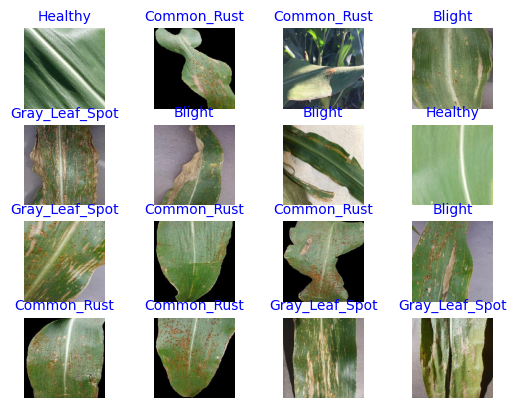

In [4]:
for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title(class_name, color= 'blue', fontsize= 10)
    plt.axis('off')
plt.show()


In [5]:
#Actual ML
#import step
#Using VGG16 bc its "easier"

In [6]:
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg16_base.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=06f42e566fe91c2939c965856845ba56155e85f24b9660349b88a3550b9cfedf
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [8]:
inputs = Input(shape=(224, 224, 3))

x = vgg16_base(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(4, activation='softmax')(x)
vgg16_model = Model(inputs, outputs)

vgg16_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16_model.fit(train_gen, epochs=3, validation_data=valid_gen)

test_loss, test_acc = vgg16_model.evaluate(test_gen, verbose=0)
print('\naccuracy:', test_acc, '  loss: ',test_loss)

Epoch 1/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 2738s 26s/step - accuracy: 0.7429 - loss: 1.1179 - val_accuracy: 0.8995 - val_loss: 0.2873
Epoch 2/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 2648s 25s/step - accuracy: 0.8532 - loss: 0.3898 - val_accuracy: 0.9171 - val_loss: 0.2546
Epoch 3/3
106/106 ━━━━━━━━━━━━━━━━━━━━ 2669s 25s/step - accuracy: 0.8750 - loss: 0.3147 - val_accuracy: 0.9372 - val_loss: 0.2207

accuracy: 0.9020100235939026   loss:  0.25908270478248596


In [9]:
#Using LIME to visualise how the ML algo pictured the disease
import lime
import lime.lime_image
from keras.applications.vgg16 import preprocess_input, decode_predictions
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
#checked to make sure there are no redundancies with the original inputs

In [11]:
model = VGG16(weights='imagenet')

explainer = lime.lime_image.LimeImageExplainer()

#selecting which image to be compared to the training model
from google.colab import files
uploaded = files.upload()

# Assuming only one file is uploaded, get its content
img_bytes = list(uploaded.values())[0]
# Convert image to RGB before resizing and preprocessing
img = np.array(Image.open(io.BytesIO(img_bytes)).convert('RGB').resize((224, 224)))
img = preprocess_input(img)

explanation = explainer.explain_instance(img, model.predict, top_labels=5, hide_color=0, num_samples=1000)

Saving Screenshot 2026-03-25 162632.png to Screenshot 2026-03-25 162632 (1).png


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6

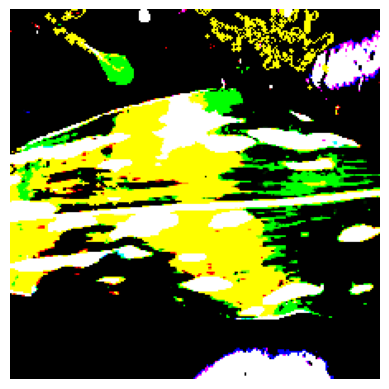

In [12]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
plt.axis('off')
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

In [13]:
predicted_probabilities = vgg16_model.predict(np.expand_dims(img, axis=0))
predicted_class_index = np.argmax(predicted_probabilities)
predicted_disease = classes[predicted_class_index]

print(f"Predicted disease: {predicted_disease}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 922ms/step
Predicted disease: Blight
